NetID: leahnl2

Assignment: Lab 9

Grade: _ / 9

Comments:

# CS448 - Lab 9: Keyword Recognition

## Part 1: Making a DTW-based Digit Recognizer

In this section we will design a simple spoken digit recognizer, based on Dynamic Time Warping (DTW). In order to make such a system we need to first collect some data, and then design a DTW routine that can compare new inputs with templates for each digit.

To start, make a set of data that will be used here. Make a dozen or so recordings of yourself speaking each of the ten digits (0 to 9). We will use one recording from each digit as the template, and the rest at testing data. In order to not spend too much time collecting the data, record all these utterances in a single (long) sound file. Use your voice activity detector to split that file into the individual spoken digits.

In order to design a digit recognizer, we will take a spoken input of a digit and compare it to each digit’s template. By finding which template is the most similar, we can classify the input as belonging to that template’s digit. In order to measure the distance between the two sequences, we have to use DTW on an appropriate feature space.

Decide which feature to use to represent your speech signals. It can be any feature that we used in the past (e.g. some type of an STFT, MFCCs, etc). When comparing a template with a new input you need to perform the following steps:

1. Compute the distance matrix between all the features of each input. This will be a $M$ by $N$ matrix in which the $(i, j)$ element will represent the distance between the $i$-th frame of the template and the $j$-th frame of the input. We will use the cosine similarity which is defined as:

$$\large{D(\mathbf{a},\mathbf{b}) = 1 - \frac{\sum a_i b_i}{\sqrt{\sum a_i^2}\sqrt{\sum b_i^2}}}$$

2. Once you obtain the distance matrix, you need to compute the cost matrix that encodes the cost of passing through a node given a previously optimal path. We will use the local constraint that to reach node $(i, j)$ you can either come from nodes $(i–1, j–1)$, $(i, j–1)$ or $(i–1, j)$.

3. Starting from the first element of the matrix (0,0), and for each element of the cost matrix you will need to perform the following steps. For node $(i, j)$ you need to examine the nodes from which you can reach it – these will be nodes $(i–1, j–1)$, $(i, j–1)$ or $(i–1, j)$ – and see which one has the lowest cost. Therefore, reaching that node from the optimal path will have the cost of the optimal preceding node plus the distance that corresponds to being at node $(i, j)$. Iterate until you calculate the cost of passing through every node. As you do that, for each node keep track of which of the three preceding nodes was the optimal one.

4. Now you can backtrack and find the optimal path. Start from the final point of the cost matrix and find the node from which you arrived there (it will be the same one that had the lowest cost above). Once you get to that node, repeat this process until you reach the beginning indexes of the two sequences. The path that you took in this process will be the optimal path that aligns the two sequences.  Note that the final point will not necessarily be the far corner of the matrix, as the two sequences might align differently. Look for the minimum value in the last row/column of the cost matrix and start backtracking from there.  Obviously, if the smallest cost is too close to the beginning, something is wrong (or you have a really bad match).

5. The distance between the two sequences will be the cost of being at the final node. Use this to perform the digit classification.

In [1]:
import utils
import numpy as np
import matplotlib.pyplot as plt
import scipy
import librosa
import hmmlearn

In [2]:
# YOUR CODE HERE
base_path = "./data/digits_"
thresholds = [6.802e-6, 4.402e-6, 1.5102e-5, 6.802e-6, 8.802e-6, 8.002e-6, 6.802e-6, 6.802e-6, 6.802e-6, 5.002e-6, 1.2502e-5]

# extract template digits
template_sr, template_x = utils.mp3readfile(base_path + "0.mp3")
template_digits, template_sounds = utils.vad(template_x, template_sr, thresholds[0])

# extract digits test data
test_digits = [[] for _ in range(10)]
test_sounds = [[] for _ in range(10)]

for i in range(1, 11):
    sound_sr, sound_x = utils.mp3readfile(base_path + f"{i}.mp3")
    extracted_stfts, extracted_sounds = utils.vad(sound_x, sound_sr, thresholds[i])
    
    for idx in range(10):
        test_digits[idx].append(extracted_stfts[idx])
        test_sounds[idx].append(extracted_sounds[idx])

# turn input sounds into mfcc features
num_digits = len(template_digits)

template_mfccs = []
for i in range(num_digits):
    template_mfccs.append(utils.mfcc(template_sounds[i], template_sr))

test_mfccs = [[] for _ in range(10)]
for i in range(num_digits):
    for idx in range(10):
        test_mfccs[i].append(utils.mfcc(test_sounds[i][idx], template_sr))

In [3]:
def plot_matrices(distance_matrix, cost_matrix, path):
    plt.figure(figsize=(7, 3))

    # plot distance matrix    
    plt.subplot(1, 2, 1)
    plt.imshow(distance_matrix, origin='lower', aspect='auto', cmap='Blues')
    plt.title("Distance Matrix")
    plt.xlabel("Template")
    plt.ylabel("Input")
    plt.colorbar()

    # plot cost matrix w/ optimal path
    plt.subplot(1, 2, 2)
    plt.imshow(cost_matrix, origin='lower', aspect='auto', cmap='Blues')
    plt.title("Cost Matrix")
    plt.xlabel("Template")
    plt.ylabel("Input")
    plt.colorbar()
    path_i, path_j = zip(*path)  # unzip path into coordinates
    plt.plot(path_j, path_i, color='red', linewidth=1, label="Optimal Path")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def compute_distance(template, test_digit, should_plot=False):

    ###############################
    # compute the distance matrix #
    ###############################
    M = template.shape[0]
    N = test_digit.shape[0]
    distance_matrix = np.zeros((M, N))
    
    for i in range(M):
        for j in range(N):
    
            # get a (i-th frame of template) and b (j-th frame of test) 
            a = np.abs(template[i])
            b = np.abs(test_digit[j])
    
            # calculate distance
            distance = 1 - (np.dot(a, b)) / (np.linalg.norm(a) * np.linalg.norm(b)) # TODO: add small number to prevent divide by zero?
            distance_matrix[i, j] = distance
    
    ###################################################
    # compute the cost matrix and record backtracking #
    ###################################################
    cost_matrix = np.zeros((M, N))
    backtrack = np.zeros((M, N), dtype=int) # 0 for diag, 1 for left, 2 for down
    
    # fill in the bottom row and left columns with just the distances
    for i in range(M):
        if i == 0:
            cost_matrix[i, 0] = distance_matrix[i, 0] 
        else:
            cost_matrix[i, 0] = distance_matrix[i, 0] + cost_matrix[i-1, 0]
        backtrack[i, 0] = 2
    
    for j in range(N):
        if j == 0:
            cost_matrix[0, j] = distance_matrix[0, j] 
        else:
            cost_matrix[0, j] = distance_matrix[0, j]  + cost_matrix[0, j-1]
        backtrack[0, j] = 1
    
    # fill in everything else with accumulated cost
    for i in range(1, M):
        for j in range(1, N):
            left = cost_matrix[i, j-1]
            down = cost_matrix[i-1, j]
            diag = cost_matrix[i-1, j-1]
    
            choices = np.array([diag, left, down]) # indices correspond to backtrack numbers
            min_idx = np.argmin(choices)
    
            cost_matrix[i, j] = distance_matrix[i, j] + choices[min_idx]
            backtrack[i, j] = min_idx
    
    ################################
    # find optimal path's distance #
    ################################
    
    # find minimum value in last row/column of cost matrix
    curr_i, curr_j = -1, -1
    min_last_row = np.argmin(cost_matrix[M-1, :])
    min_last_col = np.argmin(cost_matrix[:, N-1])
    
    if cost_matrix[-1, min_last_row] < cost_matrix[min_last_col, -1]:
        curr_i, curr_j = M-1, min_last_row
    else:
        curr_i, curr_j = min_last_col, N-1

    distance = min(cost_matrix[-1, min_last_row], cost_matrix[min_last_col, -1])

    if should_plot:
        # track the path backwards
        path = [(curr_i, curr_j)]
        while (curr_i, curr_j) != (0, 0):

            # get the previous step at current position
            next_step = backtrack[curr_i, curr_j]
        
            if next_step == 0:    # diag
                curr_i -= 1
                curr_j -= 1
            elif next_step == 1:  # left
                curr_j -= 1
            else:                 # down
                curr_i -= 1
        
            path.append((curr_i, curr_j))
        
        plot_matrices(distance_matrix, cost_matrix, path)

    return distance

Template Zero,Your browser does not support the audio element.


Test Data Zero #3,Your browser does not support the audio element.


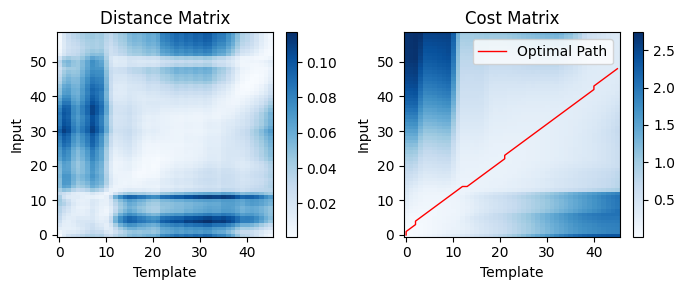

Distance:  0.3407811197685461


In [15]:
# sanity check for DTW algorithm
zero_template = np.array(template_mfccs[0])
zero_test = np.array(test_mfccs[0][2])

utils.sound(template_sounds[0], template_sr, f"Template Zero")
utils.sound(test_sounds[0][2], template_sr, f"Test Data Zero #3")

distance = compute_distance(zero_template, zero_test, should_plot=True)
print("Distance: ", distance)

In [31]:

# classify all digits
digit_names = ["zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine"]
num_tests = len(test_digits[0])
accuracy = 0.0

for number in range(num_digits):

    # loop through all the test data for that digit
    digit_results = np.zeros(num_tests, dtype=np.int32)
    for test_idx in range(num_tests):
        test_input = np.array(test_mfccs[number][test_idx])
        distances = np.zeros(num_digits)

        # loop through all the digit templates to find best match
        for template_idx in range(num_digits):
            template = np.array(template_mfccs[template_idx])

            distances[template_idx] = compute_distance(template, test_input, should_plot=False)

        result = np.argmin(distances)
        digit_results[test_idx] = int(result)

    print(f"Results for {digit_names[number]}")
    print(f"    -> classifications: {digit_results}")
    print(f"    -> accuracy: {np.sum(digit_results == number)}/{num_tests}\n")
    accuracy += (np.sum(digit_results == number) / num_tests)

accuracy /= num_digits
print("------------------------------")
print(f"Overall accuracy = {accuracy}")


Results for zero
    -> classifications: [0 8 0 0 0 0 0 8 0 0]
    -> accuracy: 8/10

Results for one
    -> classifications: [1 1 1 1 1 1 1 1 1 1]
    -> accuracy: 10/10

Results for two
    -> classifications: [2 2 2 2 2 2 2 2 2 2]
    -> accuracy: 10/10

Results for three
    -> classifications: [3 3 3 3 3 3 3 3 3 3]
    -> accuracy: 10/10

Results for four
    -> classifications: [4 4 4 4 4 4 4 4 4 4]
    -> accuracy: 10/10

Results for five
    -> classifications: [5 5 5 5 5 5 5 5 5 5]
    -> accuracy: 10/10

Results for six
    -> classifications: [6 3 3 9 8 6 6 3 6 6]
    -> accuracy: 5/10

Results for seven
    -> classifications: [7 7 7 7 7 7 7 7 7 7]
    -> accuracy: 10/10

Results for eight
    -> classifications: [8 8 8 8 8 8 8 8 8 8]
    -> accuracy: 10/10

Results for nine
    -> classifications: [9 9 9 9 9 9 9 9 9 9]
    -> accuracy: 10/10

------------------------------
Overall accuracy = 0.93


I think the DTW-based digit recognizer performed pretty well overall, despite struggling more to classify the numbers 0 and 6 correctly. I did find that using MFCC features instead of STFT features resulted in much better results as the accuracy using STFT was much lower. It also took much longer for the STFT version to run because there were many more features than the MFCC version.

## (Parts 2 & 3) Making an HMM-based Digit Recognizer

We will now redo this experiment using HMMs.  To do that you will need to install the ```hmmlearn``` package.  It is not very good software, but it beats writing your own HMM routines (although you are welcome to and will get a nice grade bump if you pull it off!).

We can use the same features as before, but we should make sure that they are somewhat Gaussian distributed so that the HMM assumptions are more valid.  If your feature representation has been using plain magnitudes (e.g. spectrograms of some sort), you can make the data more Gaussian by taking the log of the magnitudes (it will make the magnitudes that were positive and exponentially distributed, look more Gaussian).  This is a common trick in speech recognition, and it works well for many features.  Just in case you have any zeros in your features it is a good idea to add a small number inside the log (e.g. $\log( 0.1+\epsilon)$) to ensure you do not get any infinities.  Of course you need to make sure that your features tend to be more than 0.1 in that case, otherwise they will be dominated by the offset.

What will be new here is that we will train a model using multiple utterances of the same digit, as opposed to use a single template digit as with the DTW.  This allows us to learn more powerful models of a word since we can use multiple speakers, pronunciations, emotions, etc. which will result in a more robust classifier.  Train on all of the same digits, except for the first one.  Later on when you evaluate the model, use the first digit to see how well the classifier works.

We will do this in two ways, first with a fully connected network, and then with a left-to-right.

## Part 2. Fully-connected model

For a fully connected network use ```hmmlearn.hmm.GaussianHMM```.  Try different values for ```n_components``` (which is the number of states) to see what works best.  To train on multiple sequences, you need to repackage your data and make use of the ```lengths``` parameter when you call ```hmmlearn.hmm.GaussianHMM.fit()```.  Learn one HMM model for each digit using all but the first recording of that digit.  Once you have your ten trained models, present your first recording of each digits to each model and measure its likelihood using ```hmmlearn.hmm.GaussianHMM.score()```.  The digit with the highest score is the one you classify the input as.  Plot the likelihood outputs as a matrix and verify that the highest values correspond to each classifier's digit.

Training HMMs is a little bit tricky, you will likely see some ominous warnings. You can usually ignore them, but on occasion your models might diverge and give you poor results even if your code is fine.  Just to be sure, run your cells a couple of times to make sure your current output isn't a fluke.

In [105]:
# YOUR CODE HERE
import hmmlearn.hmm

# learn the HMM model for each digit using test data from before
components = 5
models = []

for number in range(num_digits):

    # get all the test data for that digit
    train_data = test_mfccs[number]

    # compute lengths of each test input and combine into one array
    lengths = [len(data) for data in train_data]
    X = np.vstack(train_data)

    # train the Gaussian HMM model
    model = hmmlearn.hmm.GaussianHMM(n_components=components).fit(X, lengths)
    models.append(model)

Results using Gaussian HMM models
    -> classifications: [0 1 2 3 4 5 6 7 8 9]
    -> accuracy: 1.0



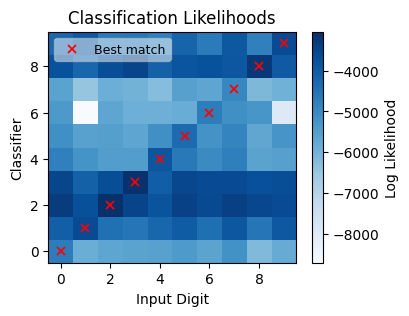

In [106]:
# classify the template digits from before
digit_names = ["zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine"]
digit_results = np.zeros(num_digits, dtype=np.int32)
likelihood_matrix = np.zeros((num_digits, num_digits))
accuracy = 0.0

for number in range(num_digits):

    X = np.array(template_mfccs[number])
    model_results = np.zeros(num_digits)

    # loop through all the HMM models to find best match
    for idx in range(num_digits):
        model = models[idx]
        score = model.score(X)
        model_results[idx] = score
        likelihood_matrix[number][idx] = score

    result = np.argmax(model_results)
    digit_results[number] = int(result)

    if result == number:
        accuracy += 1.0

accuracy /= num_digits
print(f"Results using Gaussian HMM models")
print(f"    -> classifications: {digit_results}")
print(f"    -> accuracy: {accuracy}\n")

# plot the likelihood matrix
best_match_rows = digit_results
best_match_cols = np.arange(0, num_digits)

plt.figure(figsize=(4, 3))
plt.imshow(likelihood_matrix, origin='lower', aspect='auto', cmap='Blues')
plt.title("Classification Likelihoods")
plt.xlabel("Input Digit")
plt.ylabel("Classifier")
plt.colorbar(label="Log Likelihood")
plt.plot(best_match_cols, best_match_rows, 'rx', markersize=6, markeredgewidth=1.25, label="Best match")
plt.legend(loc='upper left', framealpha=0.5, fontsize=9)
plt.show()

Using the HMM-based digit recognizer, I was able to correctly classify all of the original template recordings from before (using the previous test data as training input to the models). I also got the same results after running it multiple times to ensure it wasn't a fluke.

## Part 3. Left-to-right model (required for 4-hour credit)

Let's do this again, but this time we will use a left-to-right model.  This is a little bit more complicated, but it is worth it because it is a much more powerful model.  To do this we will use ```hmmlearn.hmm.GaussianHMM``` again, but this time we need to force the model to be left-to-right.  This is where ```hmmlearn```'s poor design shines! :)  Here is what you need to do:

1. You need to define the starting probabilities to imply that you will always start from state 0.  Make a zeros array (let's call it ```startsprob```) which is as long as the number of states and set the first element to 1.0.  This will ensure that the first state is always used first.  Inexplicably, there is no good way to directly use that in ```hmmlearn```.  You will have to manually set the initial probabilities by using ```model.startprob_ = startprob``` after you instantiate your model. When you instantiate each model, you also want to instruct it to not re-estimate the initial probabilities.  You can do this by passing the arguments: ```init_params='', params='mct'```.  It means that at each step you will estimate the means, covariances and transition probabilities, but not the initial probabilities.  This is important because we want to force the model to always start from state 0.

2. You need to define the transition matrix to be left-to-right.  Ideally you will want a form where the diagonal (except for the last state) is $1-p$, and the super-diagonal is $p$ (with $0 < p < 1$).  This means that the model will be able to stay in the same state or move to the next state, but not jump back to a previous state.  Just as before we need to force the initial structure that we want by hand, you can do that using ```model.transmat_ = transmat``` after you instantiate your model.  Since the training routine will be re-estimating the transition probabilities, you will need to set the transition priors to not change the existing zeros.  You can do that by using the the parameter ```transmat_prior```.  Its structure is a bit cumbersome, it has the same size as the transition matrix, and the values in each element indicate how much to stick with what you have vs. update via data.  Small values (e.g. 0) mean keep the values as they are, whereas larger values (e.g. 5) mean update these values from the data.  Find values for ```transmat_prior``` that seem to not change the zeros from the initial transition matrix once training is done.  You can do this by checking the transition matrix after training and making sure that the zeros are still there.

3. The initial guesses for the means and covariances are also very bad in ```hmmlearn```.  Just as above we will set them to something more reasonable by using ```model.means_ = means``` and ```model.covars_ = covars``` after you instantiate your model.  A good starting point is to take one of the training digits, split it into n equal parts (where $n$ is the number of states), and use the mean feature and its variance of each part as the initial means/covariances for the model.  This will ensure that the model starts with a reasonable guess of where the data is.

Just as before, once you learn a model for each digit, you can use the first recording of each digit to evaluate the models.  Plot the likelihood outputs as a matrix and verify that the highest values correspond to each classifier's digit.

The results in this case might not be spectacularly better than above (as should be the case), but that's a problem with ```learnhmm``` mostly.  Using better software (e.g. Kaldi) will yield much better results when you use left-to-right models.

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()